# F-μ-F depolarization function

# F-μ-F

The interaction between a muon and Fluorine atoms in solids is a simple yet interesting phenomenon for a variety of reasons.
From a theoretical point of view, the description of the spin relaxation of the muon given a nice realization of a decoherence process (Wilkinson and Blundell [2020](https://doi.org/10.1103/PhysRevLett.125.087201])). μSR makes it easy to study this phenomenon in detail, distinguishing between the "system", the F-mu-F, and the more distant nuclear spins that act as source of decoherence.

From a practical point of view, F-μ-F states can be used to identify muon sites (e.g. Mazzoli et al. [2003](https://doi.org/10.1016/S0921-4526(02)01656-3), Lancaster et al. [2007](https://doi.org/10.1103/PhysRevB.75.220408), Potočnik et al. [2010](https://doi.org/10.1103/PhysRevB.81.214420), Wilkinson et al. [2023](https://doi.org/10.1103/PhysRevB.107.144422)) or, possibly, to characterize a compound, to some extent (Wilkinson et al. [2021](https://doi.org/10.1103/PhysRevB.104.L220409)).
More generally, an experimental signal showing coherent oscillations in the muon polarization function is expected whenever the muon interacts more strongly with a limited set of nuclei with large nuclear moments (Bonfà et al. [2022](https://doi.org/10.1103/PhysRevLett.129.097205)).

The Hamiltonian describing the interaction between one muon and two nuclei is given by

$$
\hat{\mathcal{H}} = \sum_{i=1,2} \frac{\mu_0 \gamma_i \gamma_\mu}{4 \pi \hbar |\mathbf{r}_{i,\mu}|^3} \Big[ \mathbf{s}_i \mathbf{\cdot} \mathbf{s}_\mu - 3 \big(\mathbf{s}_i \mathbf{\cdot}\mathbf{\hat{r}}_{i,\mu} \big)\big(\mathbf{s}_\mu \mathbf{\cdot}\mathbf{\hat{r}}_{i,\mu} \big) \Big]
$$

Here we will consider the axial geometry which is the most common for F-μ-F states. The analytical solution for the muon polarization function, provided by Brewer et al. [1986](https://doi.org/10.1103/PhysRevB.33.7813), is known as the F-μ-F polarization function:
 
$$
G(t)=\frac{1}{6}\left[3+\cos(\sqrt{3} \omega_\text{D} t)+\left(1-\frac{1}{\sqrt{3}}\right)\cos(\frac{3-\sqrt{3}}{2}\omega_\text{D} t)+\left(1+\frac{1}{\sqrt{3}}\right)\cos(\frac{3+\sqrt{3}}{2}\omega_\text{D} t)\right]
$$

In the next steps we are going to reproduce this result with a computer simulation, but we will also evaluate the effect of the more distant nuclei.



In [1]:
import numpy as np
from copy import deepcopy
from ase.io import read
from pymatgen.core import Structure
from pymatgen.io.ase import AseAtomsAdaptor

## for plotting if needed
import matplotlib
import matplotlib.pyplot as plt

In [2]:
import sys
from pathlib import Path
ROOT = Path.cwd().parent.parent.parent

if str(ROOT) not in sys.path:
    sys.path.insert(0, str(ROOT)) 

from muonscripts.constants import constants

from muonscripts.undi_tools.celio_signal import get_signal

from muonscripts.plot_tools.muon import fancy_style_axes

In [3]:
# Importing stuff...
undi_path='/home/misah/projects/myproject/undi'
try:
    from undi import MuonNuclearInteraction
except (ImportError, ModuleNotFoundError):
    import sys
    sys.path.append(undi_path)
    from undi import MuonNuclearInteraction

## Geometry in the UNDI code

Within UNDI, the initial spin polarization and the position of detectors are assumed to be along $z$. As a consequence, from the definition of polarization function

$$
P_{i_\mu,d_p}(t)= \frac{\langle S_\mu (t) \rangle}{S_\mu(0)}\cdot \mathbf{d}_p = \frac{1}{2} \text{Tr} \left\{ \rho_{sys} (\mathbf{i}_\mu \cdot \boldsymbol{\sigma}) \left[ \boldsymbol{\sigma}(t) \cdot \mathbf{d}_p \right] \right\}
$$


where $\mathbf{i}_\mu=\mathbf{S}_\mu(0) / {S}_\mu(0)$ is the initial muon polarization vector and $\mathbf{d}_p$ is the direction used for projection (which is defined by the geometry of the experiment). In the right-hand side, $\sigma$ is the Pauli operator for the muon spin and $\rho_{sys}$ is the density matrix of the hosting system, taken to be $\rho_{sys}\sim \mathcal I$ can be taken as the inﬁnite-temperature limit of the thermal density matrix for the nuclei, which is a good approximation for the conventional muSR experiments performed about the mK.

UNDI computes $P_{i_z,d_z}(t) := P_Z(t)$. 


<div>
<img src="imgs/geometry.png" width="150px" />
</div>

(image from [Relaxation functions by P. Dalmas de Réotier](https://www.isis.stfc.ac.uk/Gallery/Relaxation%20Functions%201%20and%202%20-%20Pierre%20Dalmas.pdf))

Other geometries are possible, but are out of the scope of the present tutorial (and require some simple coding).

## The F-μ-F depolarization function

Let us consider a linear F-μ-F molecule of total length $2r$ aligned along $x$. The separation between the muon and the nearest neighboring F nuclei is predicted to be $r=1.15$ Ang. from DFT based simulations. We will place the muon at the origin of our Cartesian coordinate system. Remember that UNDI uses SI units for *all* input quantities. A few constants are defined below for convenience.

The input for UNDI is provided as a simple list of dictionaries providing the details for each nucleus. There are only two mandatory inputs: `Position` and `Label`. The former is the position of the nucleus in Cartesian space, the latter identifies the nucleus. It can be both a chemical symbol or a precise isotope. If no isotope is specified, UNDI will select **the most abundant one**. For a list of available options see (Bonfà et al [2020](https://doi.org/10.1016/j.cpc.2020.107719)).

In [4]:
import os
dpath = './'

some basic functions and inputs

In [5]:
# Collection of gammas, never really used apart from muon's one.
gammas = {
    'mu': 2*np.pi*135.53881e6,
    'F' : 2*np.pi*40.053e6,
    'H' : 2*np.pi*42.577e6,
    'V' : 2*np.pi*11.212944e6
    } # (sT)^-1

# Constants
angtom=1.0e-10 # m
h=6.6260693e-34 # Js
hbar=h/(2*np.pi) # Js
mu_0=(4e-7)*np.pi # Tm A-1
elementary_charge=1.6021766E-19 # Coulomb = ampere ⋅ second


# We define the F-mu-F function in Python below
def FmuF(tlist, r):
    omegad = (mu_0*gammas['mu']*gammas['F']*(hbar))
    omegad /=(4*np.pi*((r)**3))
    
    tomegad=tlist*omegad
    y = (1./6.)*(3+np.cos(np.sqrt(3)*tomegad)+ \
                (1-1/np.sqrt(3))*np.cos(((3-np.sqrt(3))/2)*tomegad)+ \
                (1+1/np.sqrt(3))*np.cos(((3+np.sqrt(3))/2)*tomegad))
    return y


# We define the F-mu-F function in Python below
def muF(tlist, r):
    omegad = (mu_0*gammas['mu']*gammas['F']*(hbar))
    omegad /=(4*np.pi*((r)**3))
    
    tomegad=tlist*omegad
    y = (1./6.)*(1+np.cos(tomegad)+ \
                2*np.cos((1/2)*tomegad)+ \
                2*np.cos((3/2)*tomegad))
    return y

In [6]:
# This is a linear F-mu-F along x. The distance has been obtained from DFT simulations
r=1.15 * angtom
neighbors = [
            {'Position': np.array([-r, 0., 0.]),
            'Label': 'F'},
            
            {'Position': np.array([0., 0., 0 ]),
            'Label': 'mu'},
            
            {'Position': np.array([r, 0., 0.]),
            'Label': 'F'}
        ]

# Time values, in seconds
tlist = np.linspace(0, 10e-6, 200)
tlist_us = tlist*1e6
k=4
nrep=16

We pass the input to the main class which can later be used to perform all simulations based on the geometry specified in the `atoms` variable.

## Computation

In the next cells we compute the polarization for a 10 μs time window rotating the F-μ-F "molecule" along different directions. This is required to obtain the powder average and compare the result with the experiment. 
For more details on the powder average see for example [John Wilkinson's PhD thesis](https://ora.ox.ac.uk/objects/uuid:b7c1fc6c-70f8-44f4-a7e0-6893ea7a6f61/files/dnc580n113).

The method `NS.polarization` performs the following tasks:

1. builds the Hamiltonian according to the input defined in `neighbors`,
2. finds the eigenstates of the Hamiltonian and computes the time evolution operator
3. computes the projection of the time evolved muon spin along the $z$ direction.

The muon spin in initially polarized along $z$ and this function provides the polarization function along the $z$ axis.
The option `cutoff` can be used to set the maximum length for the dipolar interactions included in the simulation.
In our case we set it to 1.2 Ang. since we want to avoid the inter-nuclear F-F interaction.

Further details are provided as comments below.

In [7]:
# Define main class
NS = MuonNuclearInteraction(neighbors, log_level='info')

# This function places the muon at the origin and rotates the positions defined in the
# input data by the angle defined by the vector given in input ([0,0,1] in this case) and z.
# [0,0,1] is actually parallel to z, so the angle is 0 deg. and no rotation is performed.
NS.translate_rotate_sample_vec([0,0,1])
# there are other functions to perform rotations based on Euler angles or the user can just provide
# properly rotated positions in the `neighbors` dictionary.

# cutoff the dipolar interaction in order to avoid F-F term
signal_FmuF_z = NS.polarization(tlist, cutoff=1.2 * angtom)

In [8]:
NS = MuonNuclearInteraction(neighbors, log_level='info')

# This time we rotate our sample by 90 deg with an axis parallel to x.
NS.translate_rotate_sample_vec([0,1,0])
signal_FmuF_y = NS.polarization(tlist, cutoff=1.2 * angtom)

In [9]:
NS = MuonNuclearInteraction(neighbors, log_level='info')
# Finallly again a rotation by 90 deg with an axis parallel to y.
NS.translate_rotate_sample_vec([1,0,0])
signal_FmuF_x = NS.polarization(tlist, cutoff=1.2 * angtom)

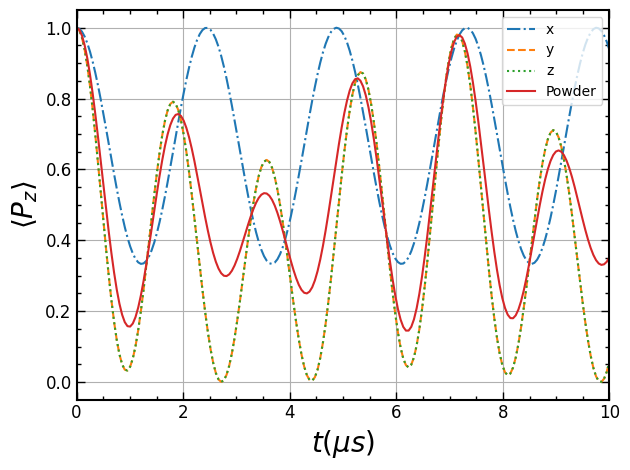

In [10]:
# Here we only plot the results

fig, ax = plt.subplots(1,1)
ax.plot(tlist_us, signal_FmuF_x, label='x', linestyle='-.')
ax.plot(tlist_us, signal_FmuF_y, label='y', linestyle='--')
ax.plot(tlist_us, signal_FmuF_z, label='z', linestyle=':')

# In zero field, the powder average is just obtained by summing the results for the three directions devided by 3.
ax.plot(tlist_us, (signal_FmuF_x+signal_FmuF_y+signal_FmuF_z)/3, label='Powder', linestyle='-')

ax.grid()
ax.legend()
fancy_style_axes(ax)

ax.set_xlabel(r'$t (\mu s)$', fontsize=20)
ax.set_ylabel(r'$\left<P_z\right>$', fontsize=20)

ax.set_xlim([0, 10])

plt.tight_layout()
plt.show()

## Comparison

We will now compare the computational result with the analytical solution. We do expect a perfect match that is indeed observed.

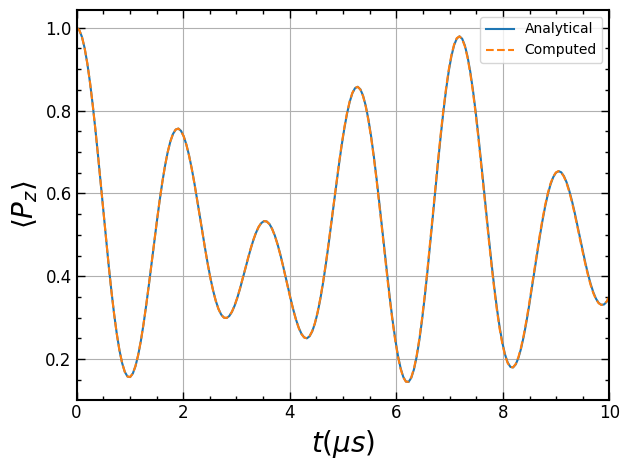

In [11]:
fig, ax = plt.subplots(1,1)
ax.plot(tlist_us, FmuF(tlist, r), label=r'Analytical', linestyle='-')
ax.plot(tlist_us, (signal_FmuF_x+signal_FmuF_y+signal_FmuF_z)/3, label='Computed', linestyle='--')
ax.set_xlabel(r'$t (\mu s)$', fontsize=20)
ax.set_ylabel(r'$\left<P_z\right>$', fontsize=20)

ax.grid()
ax.legend()
fancy_style_axes(ax)

ax.set_xlabel(r'$t (\mu s)$', fontsize=20)
ax.set_ylabel(r'$\left<P_z\right>$', fontsize=20)

ax.set_xlim([0, 10])

plt.tight_layout()
plt.show()

### One step beyond, adding inter-nuclear dipolar interactions

At this stage we can move one step forward and add the dipolar interaction between the F nuclei. This will only slightly affect our estimate since the nuclear moment of F nuclei is 3 times smaller than the one of the muon and they are 2.3 Ang. apart from each other.

The result is easily obtained by just removing the `cutoff` option from the previous set of instructions.

It should be noted that this addition does not increase the dimension of the Hilbert space and is therefore almost free.

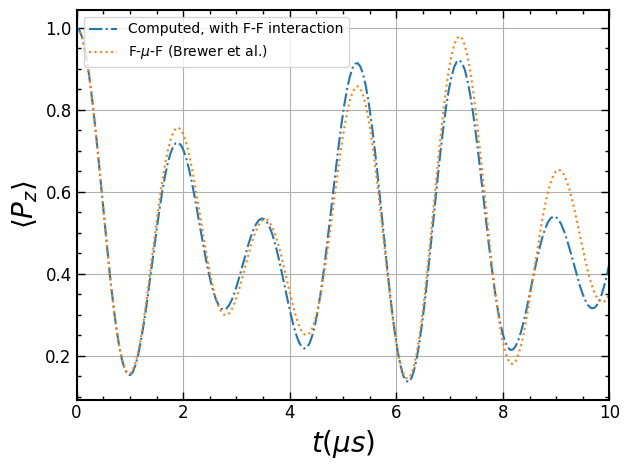

In [12]:
# no cutoff this time
NS = MuonNuclearInteraction(neighbors, log_level='info')
NS.translate_rotate_sample_vec([0,0,1])
signal_FmuF_with_Fdip = NS.polarization(tlist)

NS = MuonNuclearInteraction(neighbors, log_level='info')
NS.translate_rotate_sample_vec([0,1,0])
signal_FmuF_with_Fdip += NS.polarization(tlist)

NS = MuonNuclearInteraction(neighbors, log_level='info')
NS.translate_rotate_sample_vec([1,0,0])
signal_FmuF_with_Fdip += NS.polarization(tlist)

signal_FmuF_with_Fdip /= 3.

####################
# Plot the results #
####################
fig, ax = plt.subplots(1,1)
ax.plot(tlist_us, signal_FmuF_with_Fdip, label='Computed, with F-F interaction', linestyle='-.')

ax.plot(tlist_us, FmuF(tlist, r), label=r'F-$\mu$-F (Brewer et al.)', linestyle=':')

ax.grid()
ax.legend()
fancy_style_axes(ax)

ax.set_xlabel(r'$t (\mu s)$', fontsize=20)
ax.set_ylabel(r'$\left<P_z\right>$', fontsize=20)

ax.set_xlim([0, 10])

plt.tight_layout()
plt.show()

## Decoherence

Let's include the more distant Li nuclei in our simulation. The code will automatically select the most abundant isotope, <sup>7</sup>Li, which has spin I=3/2 (this implies a small approximation since 7.6% of Li nuclei have spin 1).
The nearest neighboring Li atoms are shown below

![](imgs/mufli.png)

The new nuclei must be added to the input, as done below.

In [13]:
# This is a linear F-mu-F along z
r_F=1.17 * angtom
r_Li=1.84 * angtom
neighbors2 = [
            {'Position': np.array([-r_F, 0., 0.]),
            'Label': 'F'},

            {'Position': np.array([0, -r_Li, 0.]),
            'Label': 'Li'},
    
            {'Position': np.array([0., 0., 0]),
            'Label': 'mu'},
            
            {'Position': np.array([r_F, 0., 0 ]),
            'Label': 'F'},

            {'Position': np.array([0, r_Li, 0.]),
            'Label': 'Li'},
        ]

In [14]:
# no cutoff this time
NS = MuonNuclearInteraction(neighbors2, log_level='info')
NS.translate_rotate_sample_vec([0,0,1])
signal_FmuF_with_Li = NS.polarization(tlist)

NS = MuonNuclearInteraction(neighbors2, log_level='info')
NS.translate_rotate_sample_vec([0,1,0])
signal_FmuF_with_Li += NS.polarization(tlist)

NS = MuonNuclearInteraction(neighbors2, log_level='info')
NS.translate_rotate_sample_vec([1,0,0])
signal_FmuF_with_Li += NS.polarization(tlist)

signal_FmuF_with_Li /= 3.

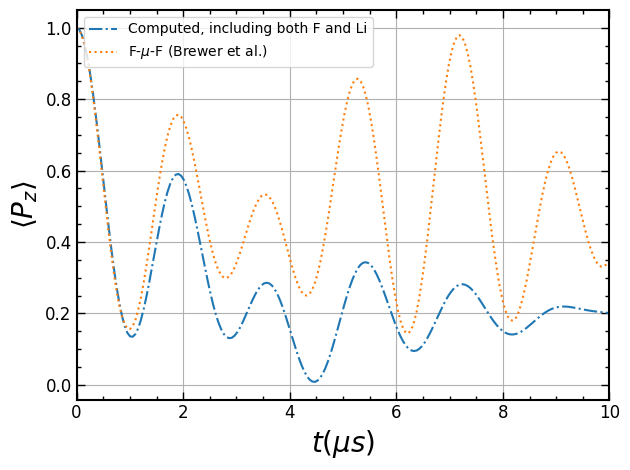

In [15]:
fig, ax = plt.subplots(1,1)
ax.plot(tlist_us, signal_FmuF_with_Li, label='Computed, including both F and Li', linestyle='-.')

ax.plot(tlist_us, FmuF(tlist, r), label=r'F-$\mu$-F (Brewer et al.)', linestyle=':')

ax.grid()
ax.legend()
fancy_style_axes(ax)

ax.set_xlabel(r'$t (\mu s)$', fontsize=20)
ax.set_ylabel(r'$\left<P_z\right>$', fontsize=20)

ax.set_xlim([0, 10])

plt.tight_layout()
plt.show()

## Advanced

Li has a quadrupolar moment different from zero. The positive muon will induce an electric field gradient at the Li nuclei and this will in turn slightly influence the result. We define the quadrupolar component as

$$
\mathcal{H}_{\mathrm{Q}, i} = \hbar \omega_{\mathrm{E}}\left[\left(\hat{\mathbf{n}} \cdot I_{i}\right)\left(\hat{\mathbf{n}} \cdot I_{i}\right)-\frac{I_{i}^{2}}{3}\right]
$$

where $\hat{\mathbf{n}}$ is the unit vector joining the muon and the $i$-th nucleus and the value for $\omega_{\mathrm{E}}$ is specified with the input `OmegaQmu` (a more general description can be done with `EFGTensor`). The value for $\omega_{\mathrm{E}}$ has been selected to magnify the expected effect. It's actual value, which is due to the perturbation introduced by the muon, can be estimated from first principles calculations and is of the order of $10^5$ Hz (the form of the quadrupolar contribution given above represents an approximation for the LiF case, a more accurate description can be obtained by considering the full EFG tensor at Li nuclei obtained for the distorted lattice. The effect of the quadrupolar contribution remains almost negligible in this case.).

In [16]:
neighbors3 = [
            {'Position': np.array([-r_F, 0., 0.]),
            'Label': 'F'},

            {'Position': np.array([0, -r_Li, 0.]),
            'Label': 'Li',
            'OmegaQmu': 3e5},
    
            {'Position': np.array([0., 0., 0]),
            'Label': 'mu'},
            
            {'Position': np.array([r_F, 0., 0 ]),
            'Label': 'F'},

            {'Position': np.array([0, r_Li, 0.]),
            'Label': 'Li',
            'OmegaQmu': 3e5},
        ]

In [17]:
# no cutoff this time
NS = MuonNuclearInteraction(neighbors3, log_level='info')
NS.translate_rotate_sample_vec([0,0,1])
signal_FmuF_with_EFG = NS.polarization(tlist)

NS = MuonNuclearInteraction(neighbors3, log_level='info')
NS.translate_rotate_sample_vec([0,1,0])
signal_FmuF_with_EFG += NS.polarization(tlist)

NS = MuonNuclearInteraction(neighbors3, log_level='info')
NS.translate_rotate_sample_vec([1,0,0])
signal_FmuF_with_EFG += NS.polarization(tlist)

signal_FmuF_with_EFG /= 3. # powder average.

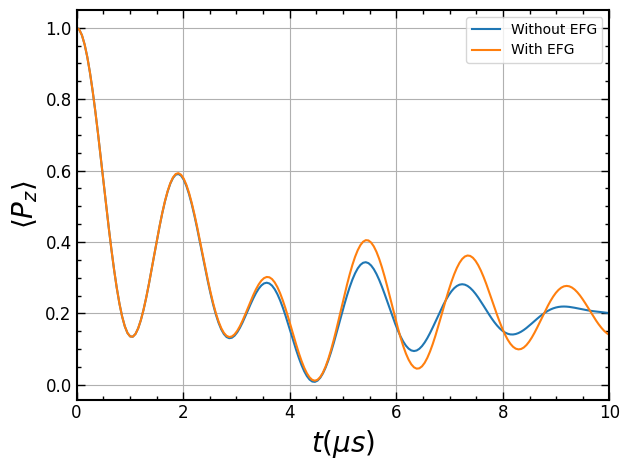

In [18]:
fig, ax = plt.subplots(1,1)
ax.plot(tlist_us, signal_FmuF_with_Li, label='Without EFG', linestyle='-')
ax.plot(tlist_us, signal_FmuF_with_EFG, label='With EFG', linestyle='-')

ax.grid()
ax.legend()
fancy_style_axes(ax)

ax.set_xlabel(r'$t (\mu s)$', fontsize=20)
ax.set_ylabel(r'$\left<P_z\right>$', fontsize=20)

ax.set_xlim([0, 10])

plt.tight_layout()
plt.show()

##### Using Celio approximation to compute signals `get_signal`

In [19]:
signal_FmuF_z = get_signal(
    neighbors=neighbors,
    tlist=tlist,

    # celio options
    k=k,
    nrep=nrep,
    algorithm='fast',
    log_level='',  # 'warn', 'info'
    single_precision=True,

    # method options
    method="single",
    orientation=[0, 0, 1]
)

[INFO] Running single-orientation signal evaluation along: [0, 0, 1]


In [20]:
signal_FmuF_x = get_signal(
    neighbors=neighbors,
    tlist=tlist,

    # celio options
    k=k,
    nrep=nrep,
    algorithm='fast',
    log_level='',  # 'warn', 'info'
    single_precision=True,

    # method options
    method="single",
    orientation=[1, 0, 0]
)

[INFO] Running single-orientation signal evaluation along: [1, 0, 0]


In [21]:
signal_FmuF_y = get_signal(
    neighbors=neighbors,
    tlist=tlist,

    # celio options
    k=k,
    nrep=nrep,
    algorithm='fast',
    log_level='',  # 'warn', 'info'
    single_precision=True,

    # method options
    method="single",
    orientation=[0, 1, 0]
)

[INFO] Running single-orientation signal evaluation along: [0, 1, 0]


In [22]:
signal_FmuF_xyz = get_signal(
    neighbors=neighbors,
    tlist=tlist,

    # celio options
    k=k,
    nrep=nrep+4,
    algorithm='fast',
    log_level='',  # 'warn', 'info'
    single_precision=True,

    # method options
    method="xyz",
)

[INFO] Running powder average using scheme: 'xyz'


In [23]:
# signal_FmuF_zcw = get_signal(
#     neighbors=neighbors,
#     tlist=tlist,

#     # celio options
#     k=k,
#     nrep=nrep+4,
#     algorithm='fast',
#     log_level='',  # 'warn', 'info'
#     single_precision=True,

#     # method options
#     method="zcw",
#     index=8
# )

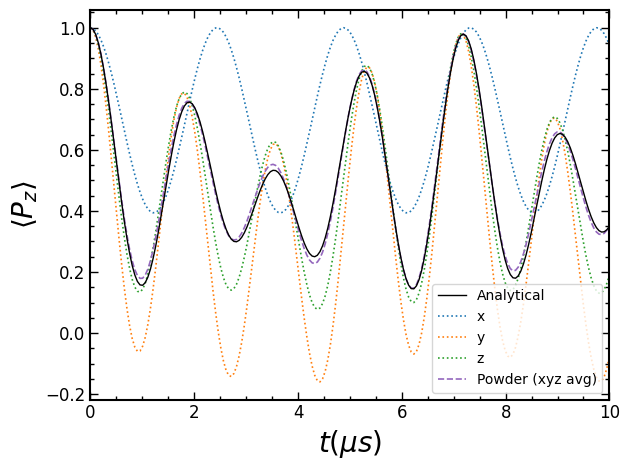

In [ ]:
fig, ax = plt.subplots(1,1)

# Reference curve (Solid black, prominent width)
ax.plot(
    tlist_us, FmuF(tlist, r), 
    color='black', label='Analytical', ls='-', lw=1.0, zorder=5
)

# Individual directional axes (x, y, z) — subtle colors, thin dashed/dotted
ax.plot(tlist_us, signal_FmuF_x, label='x', color='#1f77b4', ls=':', lw=1.2)
ax.plot(tlist_us, signal_FmuF_y, label='y', color='#ff7f0e', ls=':', lw=1.2)
ax.plot(tlist_us, signal_FmuF_z, label='z', color='#2ca02c', ls=':', lw=1.2)

# Powder averages — distinct dash patterns and medium weight
ax.plot(
    tlist_us, (signal_FmuF_x + signal_FmuF_y + signal_FmuF_z) / 3, 
    label='Powder (xyz avg)', color='#9467bd', ls='--', lw=1.2
)
# ax.plot(
#     tlist_us, signal_FmuF_xyz, 
#     label='Powder (xyz)', color='#9467bd', ls='-.', linewidth=1.2
# )
# ax.plot(
#     tlist_us, signal_FmuF_zcw, 
#     label='Powder (zcw)', color='#d62728', ls=(0, (3, 1, 1, 1)), lw=1.2
# )

ax.legend()
fancy_style_axes(ax)

ax.set_xlabel(r'$t (\mu s)$', fontsize=20)
ax.set_ylabel(r'$\left<P_z\right>$', fontsize=20)

ax.set_xlim([0, 10])

plt.tight_layout()
figname='FmuF_celiosignal.png'
figname=os.path.join(dpath, figname)
plt.savefig(figname)
plt.show()